In [1]:
import os
import gc
import json
import time
import warnings
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torchvision import models
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR
from sklearn.metrics import (confusion_matrix, classification_report, ConfusionMatrixDisplay, fbeta_score,
                             balanced_accuracy_score, f1_score, precision_recall_fscore_support)

import matplotlib.pyplot as plt
import seaborn as sns
from torch.optim import Adam 
import torch.nn.functional as F
from torch.utils.data import WeightedRandomSampler

device = torch.device("cuda" if torch.cuda.is_available() else 
                     ("mps" if torch.backends.mps.is_available() else "cpu"))

def clear_memory():
    gc.collect()
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()

In [2]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
sys.path.append(str(ROOT))

from Utils.project_utils import *
import Utils.constants as c
from Utils.transforms import *
from Utils.MushroomDataset import *
from Utils.dataLoaders import *
from Utils.lookahead import Lookahead

In [3]:
print(f"Using device: {device}")

Using device: mps


In [4]:
SPLIT_DIR = Path.cwd().resolve() / "Data" / "splits"

In [5]:
# Load the datasets
train = pd.read_csv(SPLIT_DIR / "train.csv")
val = pd.read_csv(SPLIT_DIR / "val.csv")
test = pd.read_csv(SPLIT_DIR / "test.csv")

In [6]:
# Load the class mapping
with open(SPLIT_DIR / "class_to_idx.json", "r") as f:
    train_class_to_idx = json.load(f)

In [7]:
# Define transforms (fixing the syntax error from before)
train_tfms_mild = get_train_tfms_mild() 
train_tfms_strong = get_train_tfms_strong() 
val_tfms = get_val_tfms()

print("All files loaded successfully!")

All files loaded successfully!


In [8]:
save_dir = PROJECT_ROOT / "Graphs"
save_dir.mkdir(parents=True, exist_ok=True)

In [9]:
CLASSES = sorted(train["class"].unique().tolist())

In [10]:
loaders = make_loaders(
    train,
    val,
    test,
    train_tfms_mild,
    train_tfms_strong,
    val_tfms,
    train_class_to_idx,
    CLASSES,
    c.BATCH_SIZE,
    c.NUM_WORKERS,
    device,
)

loaders

{'train_loader_mild': <torch.utils.data.dataloader.DataLoader at 0x3b387fb90>,
 'train_loader_strong': <torch.utils.data.dataloader.DataLoader at 0x3b69ffe50>,
 'val_loader': <torch.utils.data.dataloader.DataLoader at 0x3b69ff6d0>,
 'test_loader': <torch.utils.data.dataloader.DataLoader at 0x3b6a84a90>}

In [11]:
train_loader = loaders["train_loader_strong"]
val_loader = loaders["val_loader"]
test_loader = loaders["test_loader"]

In [12]:
toxic_idx = train_class_to_idx['toxic']

In [13]:
toxic_weight = 8.0 
class_weights = torch.tensor([1.0, 1.0, toxic_weight], dtype=torch.float32, device=device)

""" 
class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2):
        super().__init__()
        self.weight = weight
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.weight)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma * ce_loss).mean()
        return focal_loss
"""     

In [14]:
toxic_weight = 8.0
class_weights = torch.tensor([1.0, 1.0, toxic_weight], dtype=torch.float32, device=device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

## Training and Validation

### Load RESNET50 Model

In [15]:
clear_memory()

In [16]:
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
model.fc = nn.Linear(model.fc.in_features, len(CLASSES))
model = model.to(device)

In [17]:
base_opt = torch.optim.RAdam([
    {"params": model.conv1.parameters(), "lr": 1e-5},
    {"params": model.bn1.parameters(), "lr": 1e-5},
    {"params": model.layer1.parameters(), "lr": 1e-5},
    {"params": model.layer2.parameters(), "lr": 2e-5},
    {"params": model.layer3.parameters(), "lr": 5e-5},
    {"params": model.layer4.parameters(), "lr": 1e-4},
    {"params": model.fc.parameters(), "lr": 1e-3},
], weight_decay=0.01)

optimizer = Lookahead(base_opt, k=5, alpha=0.5)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    base_opt, 
    max_lr=[1e-5, 1e-5, 1e-5, 2e-5, 5e-5, 1e-4, 1e-3], 
    steps_per_epoch=len(train_loader), 
    epochs=30
)

In [18]:
BEST_MODEL_PATH = Path.cwd() / "best_models" / "resnet50_best.pth"
BEST_MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

In [19]:
def run_one_epoch(model, loader, criterion, optimizer, device, is_train=False, return_preds=False, scheduler=None):
    running_loss, running_correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    
    model.train() if is_train else model.eval()
    num_batches = len(loader)
    
    for i, (img, labels) in enumerate(loader):
        img, labels = img.to(device), labels.to(device)

        with torch.set_grad_enabled(is_train):
            outputs = model(img)
            loss = criterion(outputs, labels)
            
            if is_train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()
                if scheduler: scheduler.step()

        preds = outputs.argmax(1)
        running_loss += loss.item() * img.size(0)
        running_correct += (preds == labels).sum().item()
        total += img.size(0)

        if (i + 1) % 5 == 0 or (i + 1) == num_batches:
            print(f"  {'Train' if is_train else 'Val'} [{i+1}/{num_batches}] Loss: {loss.item():.4f}", end='\r')

        if return_preds:
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

    print() 
    avg_loss = running_loss / total
    avg_acc = running_correct / total

    if return_preds:
        y_true = torch.cat(all_labels).numpy()
        y_pred = torch.cat(all_preds).numpy()
        
        # Metrics Calculation
        bal_acc = balanced_accuracy_score(y_true, y_pred)
        f1_m = f1_score(y_true, y_pred, average='macro')
        f1_w = f1_score(y_true, y_pred, average='weighted')
        
        # F2 since safety first
        prec, rec, f2_score, _ = precision_recall_fscore_support(
            y_true, y_pred, labels=[toxic_idx], beta=2.0, zero_division=0
        )
        _, _, f1_tox, _ = precision_recall_fscore_support(
            y_true, y_pred, labels=[toxic_idx], beta=1.0, zero_division=0
        )
        
        metrics = (avg_loss, avg_acc, bal_acc, f1_m, f1_w, prec[0], rec[0], f1_tox[0], f2_score[0])
        return metrics, y_true, y_pred
    
    return (avg_loss, avg_acc, None, None, None, None, None, None, None), None, None

In [20]:
def train(model, train_loader, val_loader, criterion, optimizer, num_epochs, device, patience=5, scheduler=None):
    best_priority = -float("inf")
    bad_epochs = 0

    for epoch in range(num_epochs):
        # training dataset
        t_metrics, _, _ = run_one_epoch(
            model, train_loader, criterion, optimizer, device, is_train=True, scheduler=scheduler
        )
        t_loss, t_acc = t_metrics[0], t_metrics[1]
        
        # validation dataset
        v_metrics, _, _ = run_one_epoch(
            model, val_loader, criterion, optimizer, device, is_train=False, return_preds=True
        )
        v_loss, v_acc, v_bal, v_f1_m, v_f1_w, v_tox_p, v_tox_r, v_tox_f1, v_prio = v_metrics

        current_lr = optimizer.param_groups[-1]['lr']

        print(f"\n{'='*20} EPOCH {epoch+1} {'='*20}")
        print(f"TRAIN: Loss {t_loss:.4f} | Acc {t_acc:.4f}")
        print(f"VAL:   Loss {v_loss:.4f} | Acc {v_acc:.4f} | Balanced: {v_bal:.4f}")
        print(f"TOXIC: Recall: {v_tox_r:.4f} | F2 (Safety): {v_prio:.4f}")
        print(f"LR:    {current_lr:.8f}")

        # Early Stopping Logic
        if v_prio > best_priority:
            best_priority = v_prio
            bad_epochs = 0
            torch.save(model.state_dict(), BEST_MODEL_PATH)
            print(">>> New Best Model Saved!")
        else:
            bad_epochs += 1
            print(f"No improvement. Patience: {bad_epochs}/{patience}")
            if bad_epochs >= patience:
                print(f"!!! Early stopping triggered.")
                break
        
        clear_memory()

    model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
    return model

In [21]:
model = train(model, train_loader, val_loader, criterion, optimizer, num_epochs=30, device=device, patience=5, scheduler=scheduler)

  Train [151/151] Loss: 1.0295
  Val [19/19] Loss: 1.0191

==================== EPOCH 1 ====================
TRAIN: Loss 1.0889 | Acc 0.3139
VAL:   Loss 0.9973 | Acc 0.3311 | Balanced: 0.3311
TOXIC: Recall: 0.9041 | F2 (Safety): 0.6755
LR:    0.00006899
>>> New Best Model Saved!
  Train [151/151] Loss: 0.6550
  Val [19/19] Loss: 0.7234

==================== EPOCH 2 ====================
TRAIN: Loss 0.8480 | Acc 0.3323
VAL:   Loss 0.6500 | Acc 0.3333 | Balanced: 0.3333
TOXIC: Recall: 1.0000 | F2 (Safety): 0.7143
LR:    0.00015246
>>> New Best Model Saved!
  Train [151/151] Loss: 0.4482
  Val [19/19] Loss: 0.5748

==================== EPOCH 3 ====================
TRAIN: Loss 0.5816 | Acc 0.3333
VAL:   Loss 0.5050 | Acc 0.3333 | Balanced: 0.3333
TOXIC: Recall: 1.0000 | F2 (Safety): 0.7143
LR:    0.00028032
No improvement. Patience: 1/5
  Train [151/151] Loss: 0.4227
  Val [19/19] Loss: 0.4892

==================== EPOCH 4 ====================
TRAIN: Loss 0.4891 | Acc 0.3334
VAL:   Loss 0.4

In [22]:
print("FINAL EVALUATION ON TEST SET")
model.eval()
with torch.no_grad():
    # Only ONE pass through the test set
    t_metrics, y_true, y_pred = run_one_epoch(
        model, test_loader, criterion, None, device, is_train=False, return_preds=True
    )
    t_loss, t_acc, t_bal, t_f1m, t_f1w, t_prec, t_rec, t_f1tox, t_priority = t_metrics

print(f"Accuracy:  {t_acc:.4f} (Balanced: {t_bal:.4f})")
print(f"F2 Score (Priority): {t_priority:.4f}")
print("-" * 50)
print("\nDetailed Classification Report:")
print(classification_report(y_true, y_pred, target_names=CLASSES, digits=4))

FINAL EVALUATION ON TEST SET
  Val [19/19] Loss: 0.1681
Accuracy:  0.8524 (Balanced: 0.8524)
F2 Score (Priority): 0.9222
--------------------------------------------------

Detailed Classification Report:
                      precision    recall  f1-score   support

conditionally_edible     0.8997    0.8156    0.8556      1605
              edible     0.8855    0.7802    0.8295      1606
               toxic     0.7930    0.9614    0.8691      1606

            accuracy                         0.8524      4817
           macro avg     0.8594    0.8524    0.8514      4817
        weighted avg     0.8594    0.8524    0.8514      4817



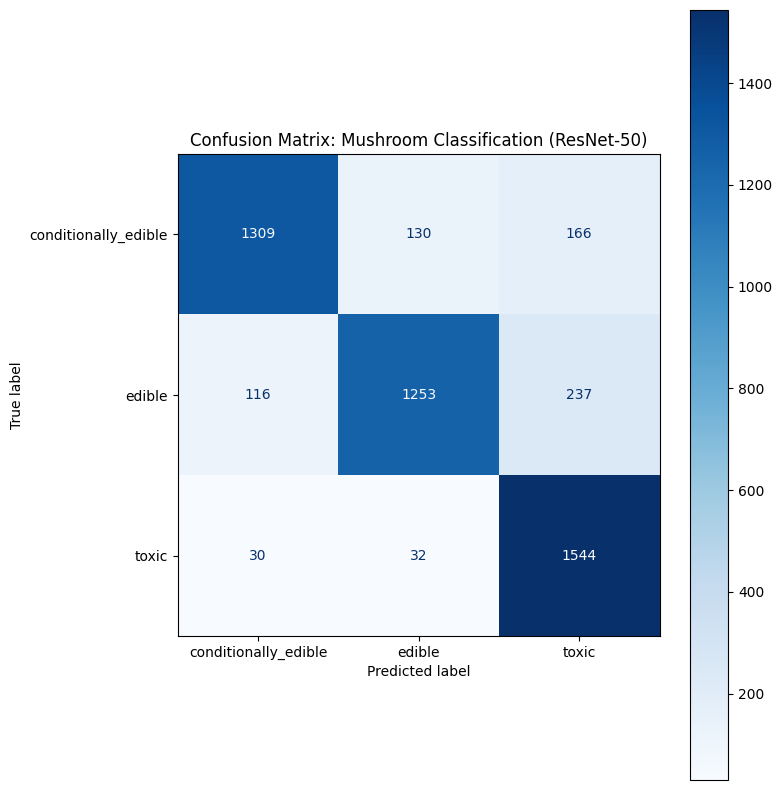

In [23]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap="Blues", values_format='d')
plt.title("Confusion Matrix: Mushroom Classification (ResNet-50)")
plt.tight_layout()
plt.savefig("resnet50_final_confusion_matrix.png", dpi=300)
plt.show()

torch.save(model.state_dict(), "Mushroom_ResNet50_Final.pth")

In [24]:
clear_memory()